## <strong> 11. 시계열 전용 연산

필요한 라이브러리: ```yfinance```, ```pandas_datareader```

In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.7 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.7 MB 1.9 MB/s eta 0:00:01
   ------------------------------------- -- 1.6/1.7 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.0 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   --------------------

In [2]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt

In [7]:
# 구글 주식 데이터 로딩
goog = yf.download("GOOG", start="2004-01-01", end="2026-04-28")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,2.478782,2.570680,2.370580,2.470382,897427216
2004-08-20,2.675672,2.694693,2.482735,2.495333,458857488
2004-08-23,2.702599,2.803391,2.693953,2.735949,366857939
2004-08-24,2.590690,2.756947,2.558575,2.748054,306396159
2004-08-25,2.618606,2.668014,2.566234,2.592914,184645512


In [ ]:
# [+] 종가(Close) 데이터만 사용하기
goog = ...
goog

<Axes: xlabel='Date'>

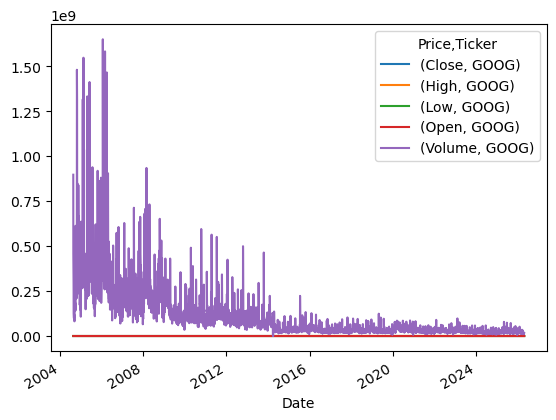

In [11]:
# [+] Lineplot 시각화
goog.plot()

#### <strong> 리샘플링(Resampling)
+ ```resample()```: 빈도를 기준으로 집계 연산
+ ```asfreq()```: 빈도 단위 별 데이터 선택

In [13]:
# [+] 다운샘플링: resample()
goog_downsampled = goog.resample('M').mean()
goog_downsampled

C:\Users\seojin\AppData\Local\Temp\ipykernel_10132\3007898505.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  goog_downsampled = goog.resample('M').mean()


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-31,2.600380,2.667986,2.545812,2.603756,2.983153e+08
2004-09-30,2.797144,2.838976,2.741066,2.766264,2.033387e+08
2004-10-31,3.785391,3.867172,3.690234,3.767098,4.914885e+08
2004-11-30,4.384811,4.495085,4.302536,4.401375,5.307326e+08
2004-12-31,4.490414,4.545482,4.434954,4.481195,2.652492e+08
...,...,...,...,...,...
2025-12-31,313.255306,316.276739,310.032089,313.735844,2.008855e+07
2026-01-31,329.048692,332.919417,324.843607,328.677453,2.086924e+07


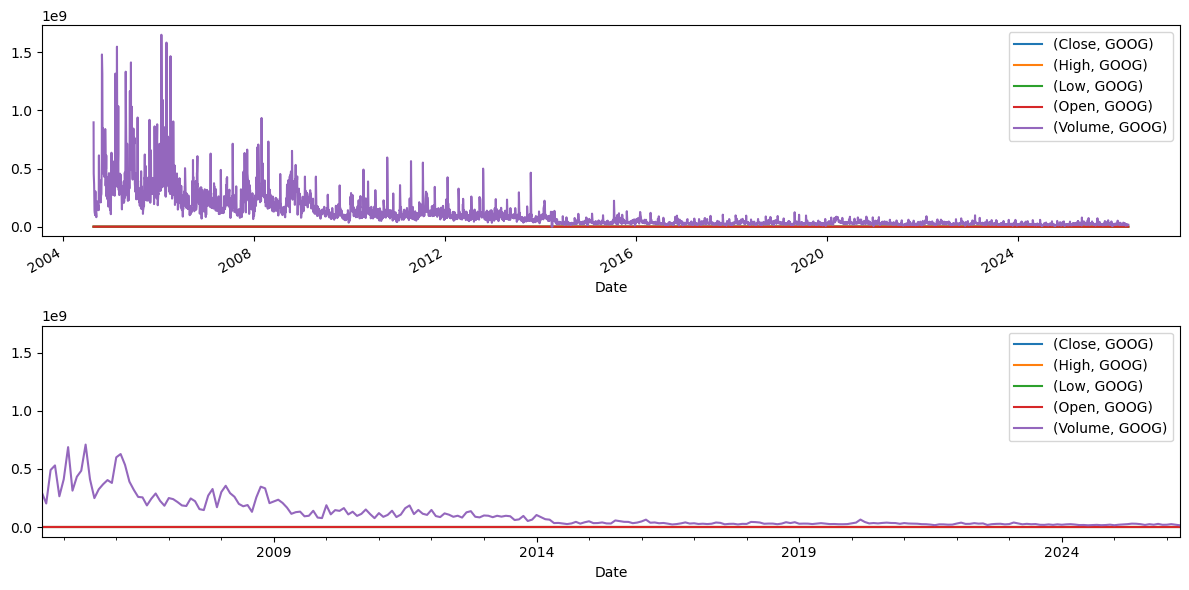

In [14]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))
goog.plot(label='original', ax=ax[0])
ax[0].legend()
goog_downsampled.plot(label='downsampled', ax=ax[1])
ax[1].legend()
plt.tight_layout()

Price            Close        High         Low        Open       Volume
Ticker            GOOG        GOOG        GOOG        GOOG         GOOG
Date                                                                   
2004-08-31    2.528931    2.562034    2.523743    2.527202   98825037.0
2004-09-30    3.201616    3.268316    3.186793    3.209027  276468402.0
2004-10-31         NaN         NaN         NaN         NaN          NaN
2004-11-30    4.495603    4.520801    4.452865    4.464229  309154460.0
2004-12-31    4.762651    4.937801    4.756968    4.921744  307889737.0
...                ...         ...         ...         ...          ...
2025-11-30         NaN         NaN         NaN         NaN          NaN
2025-12-31  313.579071  315.167979  311.980222  313.149381   10821500.0
2026-01-31         NaN         NaN         NaN         NaN          NaN
2026-02-28         NaN         NaN         NaN         NaN          NaN
2026-03-31  286.859985  287.049988  276.760010  277.540009   316

<Axes: xlabel='Date'>

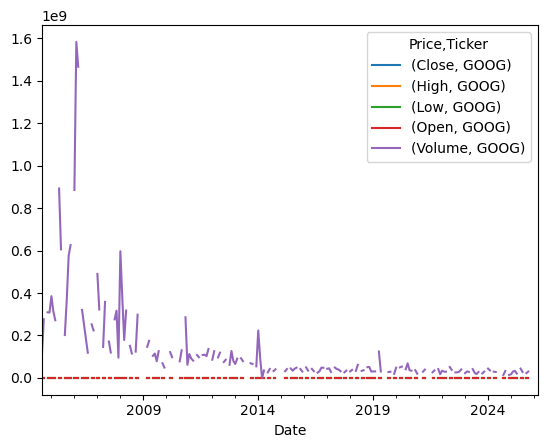

In [18]:
# [+] 다운샘플링: asfreq()
goog_downsampled = goog.asfreq('ME')
print(goog_downsampled)

goog_downsampled.plot()

In [19]:
# [+] 업샘플링: resample()
goog_upsampled = goog.resample('12h').mean()
print(goog_upsampled)

Price                     Close        High         Low        Open  \
Ticker                     GOOG        GOOG        GOOG        GOOG   
Date                                                                  
2004-08-19 00:00:00    2.478782    2.570680    2.370580    2.470382   
2004-08-19 12:00:00         NaN         NaN         NaN         NaN   
2004-08-20 00:00:00    2.675672    2.694693    2.482735    2.495333   
2004-08-20 12:00:00         NaN         NaN         NaN         NaN   
2004-08-21 00:00:00         NaN         NaN         NaN         NaN   
...                         ...         ...         ...         ...   
2026-04-25 00:00:00         NaN         NaN         NaN         NaN   
2026-04-25 12:00:00         NaN         NaN         NaN         NaN   
2026-04-26 00:00:00         NaN         NaN         NaN         NaN   
2026-04-26 12:00:00         NaN         NaN         NaN         NaN   
2026-04-27 00:00:00  348.519989  350.899994  340.809998  343.880005   

Price

#### <strong> 시프팅(Shifting)
+ ```shift(periods)``` : ```periods``` 값 만큼 시계열 이동

In [20]:
# [+] 900일 뒤로 시프팅 적용
goog_shifted = goog.shift(periods=900)
goog_shifted

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,NaN,NaN,NaN,NaN,NaN
2004-08-20,NaN,NaN,NaN,NaN,NaN
2004-08-23,NaN,NaN,NaN,NaN,NaN
2004-08-24,NaN,NaN,NaN,NaN,NaN
2004-08-25,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2026-04-21,102.786125,103.182869,101.025585,102.131504,64540100.0
2026-04-22,103.004341,103.172955,101.536397,101.705011,19738600.0


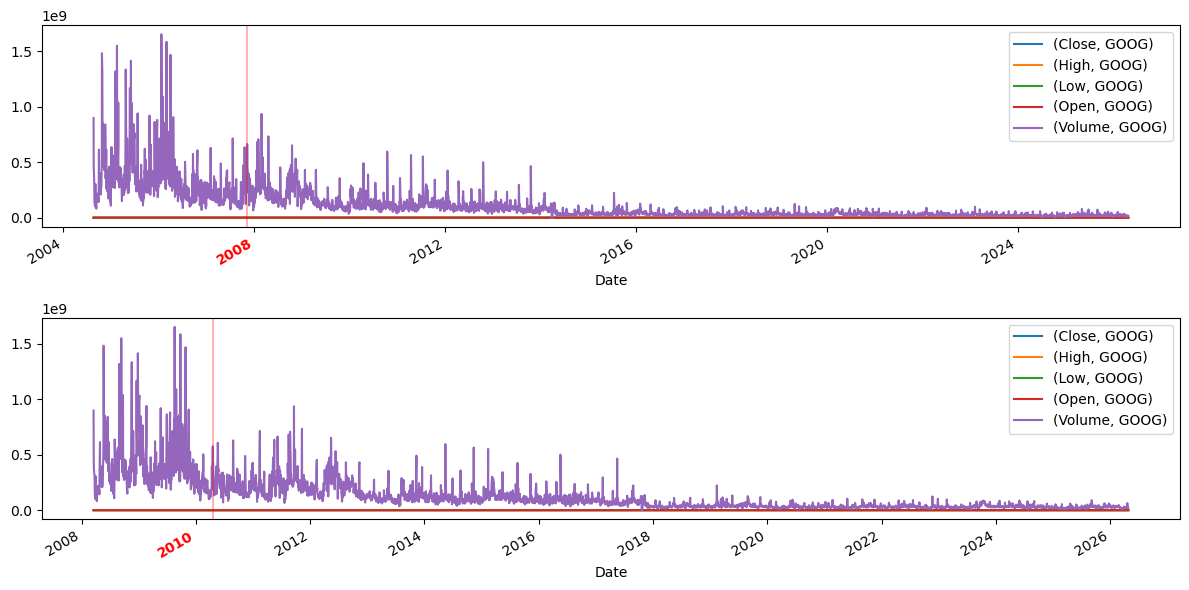

In [21]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))

# Legends and annotations
local_max = pd.to_datetime('2007-11-05')
offset = pd.Timedelta(900, 'D')

goog.plot(label='original', ax=ax[0])
ax[0].legend()
ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
ax[0].axvline(local_max, alpha=0.3, color='red')

goog_shifted.plot(label='shifted 900 days', ax=ax[1])
ax[1].legend()
ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
ax[1].axvline(local_max + offset, alpha=0.3, color='red')

plt.tight_layout()

In [22]:
# shifting 응용: 주가 변화율 계산
goog_shifted = goog.shift(periods=1) # [+] 시프팅
(goog - goog_shifted) / goog_shifted # [+] 주가 변화율 계산

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,NaN,NaN,NaN,NaN,NaN
2004-08-20,0.079430,0.048242,0.047311,0.010100,-0.488697
2004-08-23,0.010064,0.040338,0.085075,0.096426,-0.200497
2004-08-24,-0.041408,-0.016567,-0.050252,0.004424,-0.164810
2004-08-25,0.010775,-0.032258,0.002993,-0.056454,-0.397363
...,...,...,...,...,...
2026-04-21,-0.014699,-0.005867,-0.014942,-0.008787,0.133865
2026-04-22,0.021969,0.002551,0.010102,-0.002086,-0.114170


Price          Close      High       Low      Open       Volume
Ticker          GOOG      GOOG      GOOG      GOOG         GOOG
Date                                                           
2004-08-19       NaN       NaN       NaN       NaN          NaN
2004-08-20  0.196889  0.124014  0.112155  0.024951 -438569728.0
2004-08-23  0.026927  0.108697  0.211218  0.240616  -91999549.0
2004-08-24 -0.111909 -0.046444 -0.135378  0.012104  -60461780.0
2004-08-25  0.027915 -0.088932  0.007659 -0.155140 -121750647.0
...              ...       ...       ...       ...          ...
2026-04-21 -4.929993 -1.989990 -5.000000 -2.975006    1726500.0
2026-04-22  7.260010  0.859985  3.329987 -0.699982   -1669600.0
2026-04-23  0.019989  2.130005  2.100006  4.690002     487900.0
2026-04-24  4.570007  3.529999 -1.010010 -1.855011    4818800.0
2026-04-27  6.199982  7.209991  6.760010  6.160004    -859400.0

[5456 rows x 5 columns]


<Axes: xlabel='Date'>

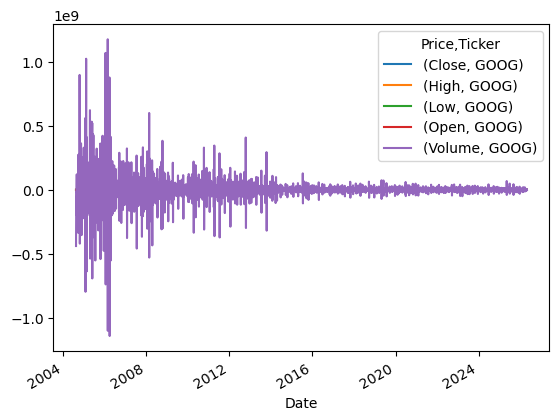

In [24]:
# shifting 응용: 차분 시계열 구하기
goog_diff = goog - goog_shifted  # [+] 차분
print(goog_diff)

goog_diff.plot()

#### <strong> 윈도잉(Windowing)

Rolling [window=365,center=False,axis=0,method=single]


<Axes: xlabel='Date'>

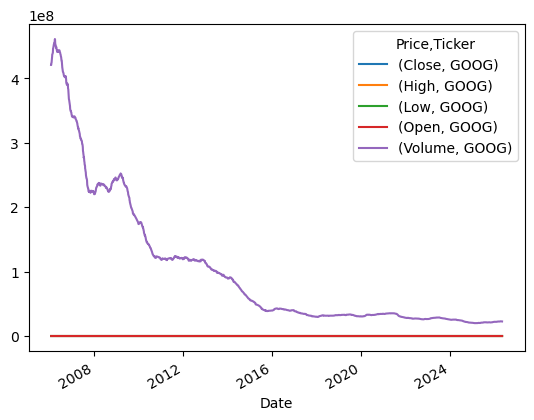

In [25]:
# [+] 365일 단위 윈도잉
goog_rolled = goog.rolling(365)
print(goog_rolled)

goog_rolled.mean().plot()

In [26]:
data = pd.DataFrame({'input': goog.values.flatten(),
                     # moving average
                     'one-year rolling_mean': goog_rolled.mean().values.flatten(), 
                     # standard deviation
                     'one-year rolling_std': goog_rolled.std().values.flatten()}, index=goog.index)
ax = data.plot(style=['-', '--', ':'])
ax.lines[0].set_alpha(0.3)

ValueError: Length of values (27280) does not match length of index (5456)